In [114]:
import numpy as np 
import pandas as pd # numpy wrapper 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [115]:
# # all the stocks that make up the snp500 index
# tickers = ['AOS', 'ABT', 'ABBV', 'ABMD', 'ACN', 'ATVI', 'ADM', 'ADBE', 'ADP', 'AAP', 'AES', 'AFL', 'A', 'AIG', 'APD', 'AKAM', 'ALK', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AMD', 'AEE', 'AAL', 'AEP',
#               'AXP', 'AMT', 'AWK', 'AMP', 'ABC', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS', 'ANTM', 'AON', 'APA', 'AAPL', 'AMAT', 'APTV', 'ANET', 'AIZ', 'T', 'ATO', 'ADSK', 'AZO', 'AVB', 'AVY', 'BKR', 'BLL', 'BAC', 'BBWI', 'BAX', 'BDX', 'WRB', 'BRK-A', 
#               'BBY', 'BIO', 'TECH', 'BIIB', 'BLK', 'BK', 'BA', 'BKNG', 'BWA', 'BXP', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'CHRW', 'CDNS', 'CZR', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CTLT', 'CAT', 'CBOE', 'CBRE', 'CDW', 'CE', 'CNC', 
#               'CNP', 'CDAY', 'CERN', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CTXS', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CMA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 
#               'GLW', 'CTVA', 'COST', 'CTRA', 'CCI', 'CSX', 'CMI', 'CVS', 'DHI', 'DHR', 'DRI', 'DVA', 'DE', 'DAL', 'XRAY', 'DVN', 'DXCM', 'FANG', 'DLR', 'DFS', 'DISCA', 'DISCK', 'DISH', 'DIS', 'DG', 'DLTR', 'D', 'DPZ', 'DOV', 'DOW', 'DTE', 'DUK', 
#               'DRE', 'DD', 'DXC', 'EMN', 'ETN', 'EBAY', 'ECL', 'EIX', 'EW', 'EA', 'EMR', 'ENPH', 'ETR', 'EOG', 'EPAM', 'EFX', 'EQIX', 'EQR', 'ESS', 'EL', 'ETSY', 'RE', 'EVRG', 'ES', 'EXC', 'EXPE', 'EXPD', 'EXR', 'XOM', 'FFIV', 'FDS', 'FAST', 'FRT', 
#               'FDX', 'FITB', 'FRC', 'FE', 'FIS', 'FISV', 'FLT', 'FMC', 'F', 'FTNT', 'FTV', 'FBHS', 'FOXA', 'FOX', 'BEN', 'FCX', 'AJG', 'GRMN', 'IT', 'GE', 'GNRC', 'GD', 'GIS', 'GPC', 'GILD', 'GL', 'GPN', 'GM', 'GS', 'GWW', 'HAL', 'HIG', 'HAS', 'HCA', 
#               'PEAK', 'HSIC', 'HSY', 'HES', 'HPE', 'HLT', 'HOLX', 'HD', 'HON', 'HRL', 'HST', 'HWM', 'HPQ', 'HUM', 'HII', 'HBAN', 'IEX', 'IDXX', 'ITW', 'ILMN', 'INCY', 'IR', 'INTC', 'ICE', 'IBM', 'IP', 'IPG', 'IFF', 'INTU', 'ISRG', 'IVZ', 'IPGP', 
#               'IQV', 'IRM', 'JBHT', 'JKHY', 'J', 'JNJ', 'JCI', 'JPM', 'JNPR', 'K', 'KEY', 'KEYS', 'KMB', 'KIM', 'KMI', 'KLAC', 'KHC', 'KR', 'LHX', 'LH', 'LRCX', 'LW', 'LVS', 'LDOS', 'LEN', 'LLY', 'LNC', 'LIN', 'LYV', 'LKQ', 'LMT', 'L', 'LOW', 'LUMN',
#               'LYB', 'MTB', 'MRO', 'MPC', 'MKTX', 'MAR', 'MMC', 'MLM', 'MAS', 'MA', 'MTCH', 'MKC', 'MCD', 'MCK', 'MDT', 'MRK', 'FB', 'MET', 'MTD', 'MGM', 'MCHP', 'MU', 'MSFT', 'MAA', 'MRNA', 'MHK', 'MOH', 'TAP', 'MDLZ', 'MPWR', 'MMM', 'MNST', 'MCO', 
#               'MS', 'MOS', 'MSI', 'MSCI', 'NDAQ', 'NTAP', 'NFLX', 'NWL', 'NEM', 'NWSA', 'NWS', 'NEE', 'NLSN', 'NKE', 'NI', 'NDSN', 'NSC', 'NTRS', 'NOC', 'NLOK', 'NCLH', 'NRG', 'NUE', 'NVDA', 'NVR', 'NXPI', 'ORLY', 'OXY', 'ODFL', 'OMC', 'OKE', 'ORCL', 
#               'OGN', 'OTIS', 'PCAR', 'PKG', 'PARA', 'PH', 'PAYX', 'PAYC', 'PYPL', 'PENN', 'PNR', 'PBCT', 'PEP', 'PKI', 'PFE', 'PM', 'PSX', 'PNW', 'PXD', 'PNC', 'POOL', 'PPG', 'PPL', 'PFG', 'PG', 'PGR', 'PLD', 'PRU', 'PEG', 'PTC', 'PSA', 'PHM', 'PVH', 
#               'QRVO', 'PWR', 'QCOM', 'DGX', 'RL', 'RJF', 'RTX', 'O', 'REG', 'REGN', 'RF', 'RSG', 'RMD', 'RHI', 'ROK', 'ROL', 'ROP', 'ROST', 'RCL', 'SPGI', 'CRM', 'SBAC', 'SLB', 'STX', 'SEE', 'SRE', 'NOW', 'SHW', 'SBNY', 'SPG', 'SWKS', 'SJM', 'SNA',
#               'SEDG', 'SO', 'LUV', 'SWK', 'SBUX', 'STT', 'STE', 'SYK', 'SIVB', 'SYF', 'SNPS', 'SYY', 'TMUS', 'TROW', 'TTWO', 'TPR', 'TGT', 'TEL', 'TDY', 'TFX', 'TER', 'TSLA', 'TXN', 'TXT', 'TMO', 'TJX', 'TSCO', 'TT', 'TDG', 'TRV', 'TRMB', 'TFC', 'TWTR', 
#               'TYL', 'TSN', 'USB', 'UDR', 'ULTA', 'UAA', 'UA', 'UNP', 'UAL', 'UNH', 'UPS', 'URI', 'UHS', 'VLO', 'VTR', 'VRSN', 'VRSK', 'VZ', 'VRTX', 'VFC', 'VTRS', 'V', 'VNO', 'VMC', 'WAB', 'WMT', 'WBA', 'WM', 'WAT', 'WEC', 'WFC', 'WELL', 'WST', 'WDC', 
#               'WRK', 'WY', 'WHR', 'WMB', 'WTW', 'WYNN', 'XEL', 'XYL', 'YUM', 'ZBRA', 'ZBH', 'ZION', 'ZTS']

# stocks that i download from yfinance
tickers = ["AAPL","MSFT","AMZN","GOOGL","GOOG","META","NVDA","TSLA","BRK-B","JPM","V","UNH","JNJ","WMT","PG","MA","HD","BAC","PFE","DIS","ADBE","CMCSA","NFLX","KO","XOM","MRK","PEP","INTC","T","ABBV","COST","CRM","AVGO","NKE","MCD","TMO","TXN","ORCL","CSCO","LLY","QCOM","C","NEE","PM","BMY","AMAT","LOW","SBUX",
"RTX","AXP","INTU","GILD","MDT","BLK","HON","UPS","GS","MS","PLD","ISRG","LMT","BKNG","ZM","SNY","SQ","ADP","DUK","GE","CVX","SPGI","NOW","ANTM","AMGN","CAT","SYK","CB","TGT","DE","PNC","USB","BDX","ADSK","MO","ELV","CL","FIS","TJX","CI","SCHW","MDLZ","MMC","ETN","VRTX","AON","ICE","COF",
"BSX","NOC","KMB","ATVI","AEP","EOG","HUM","KMI","CME","CSX","SHW","MCO","LRCX","BIIB","ZTS","WM","TFC","EQIX","APD","SO","ECL","ROP","DHR","MU","LULU","ILMN","EA","PNR","CLX","KLAC","MAR","PAYX","ADM","OXY","STZ","AIG","DLR","SLB","EXC","BBY","HCA","EXPE","NVR","ALGN","MSI","VZ","ESS",
"PLTR","SYF","ORLY","PGR","AKAM","KR","F","HPE","EW","WBA","HSY","TFX","NEM","CPRT","CTAS","FTNT","DG","DOW","APH","ANET","FTV","RMD","URI","A","PNW","VFC","GLW","ABT","AFL","AEE","PEG","DLTR","NCLH","MKTX","CPB","NRG","PXD","KHC","NLOK","AES","CFG","CNP","MET","ETR","VRSK","PPL","ARE",
"BBWI","BKR","BLL","BAX","BR","BRK-A","BWA","CARR","CBRE","CF","CHTR","CHRW","CINF","CMA","CNC","COG","COP","COTY","CPRT","CRL","CTVA","CUK","DD","DOV","DPZ","DTE","DVN","DXC","EBAY","ED","EFX","EIX","EL","EMN","EMR","EPAM","EQT","ES","ESS","ETN","ETR","EVRG","EW","EXPD","FB","FDX",
"FE","FFIV","FIS","FISV","FITB","FLIR","FMC","FOX","FOXA","FRC","GD","GPN","GWW","HBI","HD","HES","HIG","HOLX","HPQ","HRL","HSIC","HST","HUM","IBM","IFF","IP","IPG","IPGP","IQV","IR","IRM","ISRG","ITW","IVZ","JBHT","JCI","JNPR","KDP","KEY","KIM","KMX","KO","L","LB","LDOS","LEG","LEN","LHX",
"LKQ","LLY","LNC","LNT","LOW","LRCX","LUV","LYB","LYV","M","MAA","MCHP","MCK","MDT","MGM","MHK","MKC","MLM","MNST","MOS","MPC","MRK","MRO","MS","MSCI","MTB","MTD","NCLH","NDAQ","NEE","NEM","NKE","NTAP","NUE","NVDA","NVR","NWL","NWS","O","ODFL","PAYC","PCAR","PCG","PENN","PEP","PFE","PFG",
"PG","PH","PHM","PKG","PKI","PLD","PNC","PNR","PNW","PPG","PRU","PSA","PSX","PVH","PWR","PYPL","QCOM","QRVO","RCL","RE","RF","RHI","RJF","RL","ROK","ROL","ROP","ROST","RSG","RTX","SBAC","SEE","SHEL","SHW","SIG","SJM","SLB","SNA","SNPS","SO","SPG","SPGI","SRE","STE","STT","STX","STZ",
"SWK","SWKS","SYY","TAP","TD","TDG","TEL","TER","TFX","TGT","TIF","TJX","TMO","TMUS","TRV","TSCO","TSLA","TSN","TROW","TRMB","TTWO","TWTR","TXN","TXT","TYL","UA","UAA","UAL","UDR","UHS","ULTA","UNH","UNM","UNP","UPS","URI","V","VFC","VLO","VMC","VTR","WAB","WAT","WDC","WEC","WELL","WFC",
"WHR","WLTW","WMB","WM","WMT","WRB","WRK","WY","WYNN","XEL","XLNX","XOM","XRAY","XYL","YUM","ZBH","ZBRA","ZION","ZTS","SPY","QQQ","VOO","VTI","IWM","DIA","EEM","EFA","XLF","XLE","XLY","XLK","XLV","XLI","XLP","XLB","XLU","XLC","SMH","GDX","GLD","SLV","ARKK","ARKG","ARKW","ARKF",
"VUG","VOOG","IVV","SCHG","VTV","IWD","IWF","EWT","EWJ","EWY","EWZ","EWG","EWC","EWU","EWH","EWQ","EWA","EWL","EWS","EWP","EWX","TSM","BABA","TCEHY","JD","PDD","NTES","NIO","LI","XPEV","BIDU","SHOP","SQ","SQM","BYND","WORK","DOCU","CRWD","NET","OKTA","DDOG","FSLY","ROKU","SNOW","PLTR","ABNB","UBER",
"LYFT","GRUB","PYPL","ETSY","NTDOY","MELI","SEA","ASML","SAP","HDB","HDFC","INFY","TCS","WIPRO","RELIANCE","BP","RDS-A","RDS-B","TOT","ENI","E.ON","RIO","BHP","VALE","TEVA","SAN","SIEGY","SONY","SMCI","ASAN","FVRR","DASH","COIN","MSTR","RIVN","LCID","QS","WKHS","NOK","ERIC","BB","GPRO","DELL","WDAY","MTCH","PINS"]



In [116]:
# stocks_histories = yf.download(tickers, period="5y", auto_adjust=True, group_by='ticker')
# bulk downloading stocks histories
stocks_histories = yf.download(tickers, period="5y", auto_adjust=True)['Close'] # reflect total return adjusted prices
stocks_histories


[*********************100%***********************]  508 of 508 completed

30 Failed downloads:
['BLL', 'WBA', 'ATVI', 'TIF', 'E.ON', 'RE', 'RDS-A', 'SQ', 'HDFC', 'XLNX', 'TCS', 'JNPR', 'GRUB', 'TWTR', 'WIPRO', 'PKI', 'WRK', 'ANTM', 'RDS-B', 'FRC', 'FLIR', 'NLOK', 'WLTW', 'WORK', 'MRO', 'COG', 'HES', 'RELIANCE', 'PXD']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')
['ENI']: YFPricesMissingError('possibly delisted; no price data found  (period=5y)')


Ticker,A,AAPL,ABBV,ABNB,ABT,ADBE,ADM,ADP,ADSK,AEE,...,XOM,XPEV,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZM,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2020-11-16,106.586243,117.106308,80.938408,NaN,103.853516,460.950012,43.905975,159.768326,248.789993,72.869339,...,31.188557,44.099998,45.052086,92.143684,95.461868,140.146286,345.980011,33.512547,399.149994,158.025909
2020-11-17,106.189926,116.220490,81.637856,NaN,103.296173,467.950012,43.688225,158.956146,252.710007,69.646248,...,31.605387,42.910000,44.344749,90.781250,94.805771,140.080933,340.790009,33.386086,401.630005,158.159714
2020-11-18,102.410530,114.896599,81.234642,NaN,100.290321,459.470001,43.223274,156.257996,252.220001,68.315552,...,30.412102,42.180000,44.353809,89.863510,94.924225,138.252411,337.579987,32.829643,415.040009,156.314590
2020-11-19,105.049347,115.490372,82.016373,NaN,101.414078,466.410004,42.916229,156.682114,256.880005,67.702049,...,30.567398,48.110001,44.317551,89.286362,95.926598,136.703705,358.390015,32.365952,414.290009,159.001083
2020-11-20,107.185509,114.224876,82.979141,NaN,101.313583,462.920013,42.644276,154.552505,254.889999,67.788445,...,30.191450,53.889999,44.798168,89.295815,95.671471,136.153275,354.989990,32.273209,439.600006,158.895950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-10,146.360001,269.429993,218.710007,120.199997,125.889999,328.850006,56.000000,254.059998,298.720001,104.339996,...,117.194946,26.040001,11.000000,151.050003,148.259995,88.730003,260.630005,52.158627,83.160004,119.790001
2025-11-11,149.419998,275.250000,225.169998,122.529999,127.000000,333.220001,57.630001,255.199997,301.859985,105.190002,...,118.741417,28.070000,10.980000,149.779999,150.750000,88.500000,255.169998,52.218109,84.589996,120.120003
2025-11-12,151.520004,273.470001,233.229996,121.690002,128.820007,337.049988,57.750000,254.550003,301.739990,105.720001,...,117.095818,27.280001,10.840000,149.869995,149.369995,90.029999,255.690002,52.000000,84.699997,121.250000


In [117]:
# remove tickers that have no data at all (NaNs only) - (axis=1 for columns, axis=0 for rows)
stocks_histories = stocks_histories.dropna(axis=1, how='all') # how='all' = drop only if all values are NaN

# fill small gaps using previous day's price (forward fill), then backfill any remaining NaNs
stocks_histories = stocks_histories.fillna(method='ffill').fillna(method='bfill')

print("prices shape after cleanup:", stocks_histories.shape)


prices shape after cleanup: (1256, 478)


C:\Users\35387\AppData\Local\Temp\ipykernel_32948\565499814.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stocks_histories = stocks_histories.fillna(method='ffill').fillna(method='bfill')


In [118]:
# calculate the daily returns for each stock 
daily_returns = stocks_histories.pct_change(fill_method=None).dropna()

# calculate the anunual means
annual_means_returns = daily_returns.mean() * 252 # 252 trading days in a year

# calculate annual returns variance 
annual_returs_variance = daily_returns.var() * 252


In [119]:
# stocks = list(stocks_histories.columns)
tickers = annual_returs_variance.index.tolist() 
df2 = pd.DataFrame({'Stock Symbols': tickers})

# remove the date column - create columns for stock symbols and their variances 
# df2['Variances'] = annual_returs_variance.values
# df2['Returns'] = annual_means_returns.values

df2 = pd.DataFrame({
    'Stock Symbols': tickers,
    'Variances': annual_returs_variance.reindex(tickers).values,
    'Returns': annual_means_returns.reindex(tickers).values
})
# show the data 
df2



,Stock Symbols,Variances,Returns
0,A,0.080925,0.104705
1,AAPL,0.079046,0.208874
2,ABBV,0.050164,0.237187
3,ABNB,0.221061,0.075876
4,ABT,0.046737,0.069434
...,...,...,...
473,ZBH,0.067356,-0.055041
474,ZBRA,0.152928,0.004366
475,ZION,0.189768,0.180339
476,ZM,0.207242,-0.207998


c:\Users\35387\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\35387\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\35387\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\35387\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

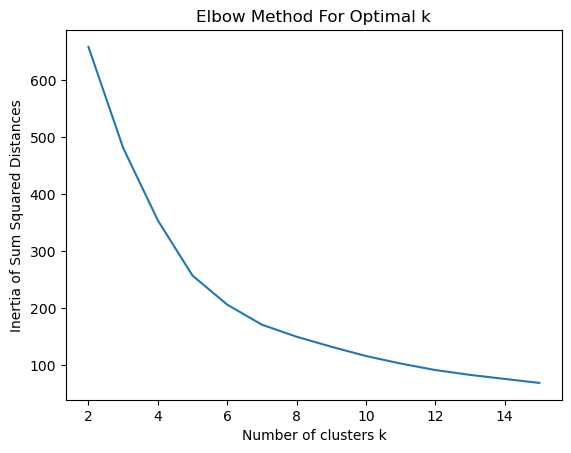

In [120]:
# using the elbow method to find the optimal number of clusters

# get and store the annual returns and annualvariances
X = df2[['Returns', 'Variances']].values

# https://datadave1.medium.com/k-means-clustering-to-diversify-your-stock-portfolio-50d807e90835
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# checking for NaN values
# print(df2[['Returns','Variances']].isna().sum()) # should be 0 for both
# print("means:", Xs.mean(axis=0))
# print("stds: ", Xs.std(axis=0, ddof=0))

# inertia is the within cluster sum of squared distances from each sample to its nearest cluster center
# when the interia on the graph starts to flatten out that is the optimal number of clusters - adding more clusters doesnt improve the model significantly
inertia = []
# evaluate different number of clusters from 2 to 15
for k in range(2,16):
    # create and train the kmeans model 
    # Creates a KMeans instance to find k clusters in the data
    # n_init=50 tells kmeans to run the algorithm 50 times with different initial centroids and choose the best result
    kmeans = KMeans(n_clusters=k, n_init=50, random_state=42)

    # train the model on the data 
    kmeans.fit(Xs)
    # append the inertia to the list - sum of squared distances to nearest cluster center
    inertia.append(kmeans.inertia_)

# plot the elbow graph 
plt.plot(range(2,16), inertia)
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia of Sum Squared Distances')
plt.show()

In [121]:
# get and show the cluster grouops for each stock
kmeans = KMeans(n_clusters=5).fit(Xs)  
labels = kmeans.labels_
labels

c:\Users\35387\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 4, 1, 1, 4, 1, 1,
       4, 0, 1, 0, 0, 1, 2, 4, 4, 4, 0, 1, 0, 2, 0, 0, 1, 1, 0, 0, 4, 4,
       1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 4, 1, 4, 4, 1, 1, 0, 1, 1, 1, 0,
       4, 0, 1, 0, 1, 4, 2, 4, 1, 0, 0, 1, 0, 1, 4, 1, 1, 1, 1, 4, 1, 4,
       1, 4, 1, 4, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 4, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 4, 0, 1, 4, 1, 1, 1, 4, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 4, 2, 4, 1, 0, 1, 4, 4, 1, 1, 4, 4, 4, 0, 0, 4, 1, 0, 4,
       1, 1, 4, 1, 1, 4, 1, 0, 1, 1, 1, 0, 4, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 4, 0, 1, 4, 1, 1, 1, 1, 4, 1, 1,
       0, 1, 1, 1, 4, 2, 1, 0, 1, 1, 2, 1, 4, 1, 1, 1, 1, 4, 0, 0, 0, 2,
       1, 4, 1, 1, 1, 1, 0, 4, 1, 1, 1, 4, 1, 4, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 4, 1, 4, 1, 1, 1, 2, 1, 0, 1, 4, 0, 1, 1, 1, 2, 4, 0, 0, 1, 4,
       1, 4, 4, 1, 4, 4, 4, 1, 0, 1, 1, 1, 0, 4, 4,

In [122]:
df2['Cluster_labels'] = labels
df2

,Stock Symbols,Variances,Returns,Cluster_labels
0,A,0.080925,0.104705,1
1,AAPL,0.079046,0.208874,1
2,ABBV,0.050164,0.237187,1
3,ABNB,0.221061,0.075876,0
4,ABT,0.046737,0.069434,1
...,...,...,...,...
473,ZBH,0.067356,-0.055041,0
474,ZBRA,0.152928,0.004366,0
475,ZION,0.189768,0.180339,4
476,ZM,0.207242,-0.207998,0


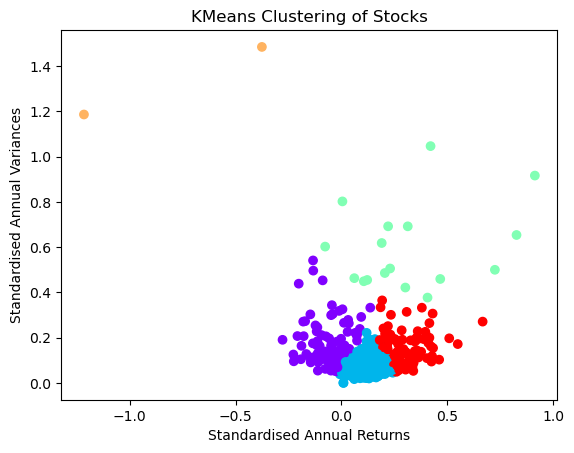

In [123]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')
plt.title('KMeans Clustering of Stocks')
plt.xlabel('Standardised Annual Returns') # assets avergae performance over a year 
plt.ylabel('Standardised Annual Variances') # measures risk / volatility - risk / return trade-off 
plt.show()

### Risky :
red - the higher the dot the risker the stock is as it has higher volatility (larger losses but potentially higher rewards)

### Moderatley risky :
blue - moderate risk by high reward

### Conservative : 
orange, purple , green - steady movement so will have less losses and less reward 

In [124]:
# display stocks in each cluster group
for cluster, group in df2.groupby('Cluster_labels'):
    print(f"Cluster {cluster} ({len(group)} stocks):")
    print(group['Stock Symbols'].tolist())
    print()


Cluster 0 (82 stocks):
['ABNB', 'ADBE', 'AES', 'ALGN', 'ARE', 'ARKG', 'ARKK', 'BABA', 'BAX', 'BBWI', 'BBY', 'BIDU', 'BIIB', 'CHTR', 'CLX', 'CMCSA', 'CNC', 'COTY', 'CPB', 'CRL', 'DG', 'DIS', 'DOCU', 'DOW', 'DXC', 'EL', 'EMN', 'EPAM', 'ETSY', 'FIS', 'FISV', 'FMC', 'FVRR', 'GPN', 'GPRO', 'HBI', 'HRL', 'HUM', 'IFF', 'ILMN', 'INTC', 'IPGP', 'JD', 'KMX', 'LEG', 'LULU', 'LUV', 'LYB', 'MCHP', 'MHK', 'MKC', 'MKTX', 'MTCH', 'NCLH', 'NIO', 'NKE', 'NWL', 'OKTA', 'PAYC', 'PENN', 'PINS', 'PPG', 'PYPL', 'QRVO', 'RHI', 'RIVN', 'SBAC', 'STZ', 'SWK', 'SWKS', 'TFX', 'TGT', 'UA', 'UAA', 'UPS', 'VFC', 'WHR', 'XRAY', 'ZBH', 'ZBRA', 'ZM', 'ZTS']

Cluster 1 (281 stocks):
['A', 'AAPL', 'ABBV', 'ABT', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AFL', 'AIG', 'AKAM', 'AMGN', 'AMZN', 'AON', 'APD', 'ARKF', 'ARKW', 'BAC', 'BDX', 'BHP', 'BLK', 'BMY', 'BP', 'BR', 'BRK-A', 'BRK-B', 'BSX', 'BWA', 'C', 'CARR', 'CB', 'CFG', 'CHRW', 'CI', 'CINF', 'CL', 'CME', 'CNP', 'COST', 'CPRT', 'CRM', 'CSCO', 'CSX', 'CTAS', 'CTVA', 'CVX', 'DD